Data klasörünün içinde UCMERCED datasetinde klasörler train/valid/test şeklinde ayrılmamış. Ayrıca NWPU datasetinde ise sadece train ve test klasörü var,valid klasörü yok. 

önceliğimiz bunu düzeltmek olacak.
Doğru klasörleme yapısına böldüğümüz datasetleri "split_data" klasöründe olacak.


In [1]:
#split-folders kütüphanesi sayesinde veri setimizi train,val ve test olarak ayırabiliriyoruz.
%pip install split-folders

import splitfolders

#UCMERCED veri setimizi yüzde 70 train, yüzde 10 validation ve yüzde 20 test olarak ayırıyoruz.
splitfolders.ratio("../data/ucmerced/Images",output="../split_data/ucmerced",seed=42,ratio=(0.7,0.1,0.2))

#NWPU veri setimizin train kısmının yüzde 80 train, yüzde 20 validation olarak ayırıyoruz.Test verisi zaten olduğu için ellemiyoruz.
splitfolders.ratio("../data/nwpu/train/train",output="../split_data/nwpu",seed=42,ratio=(0.8,0.2))


Note: you may need to restart the kernel to use updated packages.


##Veri setlerininin analizi

In [ ]:
import torch 
from torchvision.datasets import ImageFolder

#veri setleriinin yollarını tanımlıyoruz.

nwpu_train_path = "../split_data/nwpu/train"
nwpu_val_path = "../split_data/nwpu/val"
nwpu_test_path = "../split_data/nwpu/test"

ucmerced_train_path = "../split_data/ucmerced/train"
ucmerced_val_path = "../split_data/ucmerced/val"
ucmerced_test_path = "../split_data/ucmerced/test"
###############
#NWPU veri seti ile ilgili bilgiler
#Image Folder (görsel,sınıf) şeklinde tuple veri verir

nwpu_train = ImageFolder(nwpu_train_path)
nwpu_val = ImageFolder(nwpu_val_path)
nwpu_test = ImageFolder(nwpu_test_path)
nwpu_toplam_resim_sayisi = len(nwpu_val)+ len(nwpu_train) +len(nwpu_test)
nwpu_siniflar = nwpu_train.classes

print(f"NWPU verisinde toplamda {nwpu_toplam_resim_sayisi} gorsel icermektedir")
print(f"NWPU verisinde train için {len(nwpu_train)} tane görsel var")
print(f"NWPU verisinde validasyon için {len(nwpu_val)} tane görsel var")
print(f"NWPU verisinde test için {len(nwpu_test)} tane görsel var")
print(f"NWPU verisindeki toplam sinif sayisi {len(nwpu_train.classes)}")
print(f"NWPU verisindeki siniflar {nwpu_siniflar}")

print("*-*"*20)




nwpu_sinif_indexleri = nwpu_train.class_to_idx


nwpu_sinif_indexleri.values() #mwpu veri setindeki her sınıfın index sayısını verir

nwpu_train_list=list(nwpu_train)



for index in nwpu_sinif_indexleri.values():
    sayac=0

    for i in nwpu_train_list:

        if i[1] == index :
                sayac+=1
    print(f"NWPU verisetinde {index+1}.nci siniftaki toplam train eleman sayisi {sayac}")
    sayac=0




In [ ]:
from torchvision.datasets import ImageFolder

#Image Folder (görsel,sınıf) şeklinde tuple verir

ucmerced_train = ImageFolder(ucmerced_train_path)
ucmerced_val = ImageFolder(ucmerced_val_path)
ucmerced_test = ImageFolder(ucmerced_test_path)
ucmerced_toplam_resim_sayisi = len(ucmerced_val)+ len(ucmerced_train) +len(ucmerced_test)
ucmerced_siniflar = ucmerced_train.classes

###############
#NWPU veri seti ile ilgili bilgiler

print(f"UCMERCED verisinde toplamda {ucmerced_toplam_resim_sayisi} gorsel icermektedir")
print(f"UCMERCED verisinde train için {len(ucmerced_train)} tane görsel var")
print(f"UCMERCED verisinde validasyon için {len(ucmerced_val)} tane görsel var")
print(f"UCMERCED verisinde test için {len(ucmerced_test)} tane görsel var")
print(f"UCMERCED verisindeki toplam sinif sayisi {len(ucmerced_train.classes)}")
print(f"UCMERCED verisindeki siniflar {ucmerced_siniflar}")
print("*-*"*20)




#ucmerced veri setindeki her sınıfın index sayısını verir
ucmerced_sinif_indexleri = ucmerced_train.class_to_idx.values()

ucmerced_train_list=list(ucmerced_train)


for index in ucmerced_sinif_indexleri:
    sayac=0

    for i in ucmerced_train_list:

        if i[1] == index :
                sayac+=1
    print(f"UCMERCED verisetinde {index+1}.nci siniftaki toplam train eleman sayisi {sayac}")
    sayac=0


##Veri setlerindeki görüntüler ve görüntü özellikleri

In [ ]:
#nwpu train verisetindeki ilk görselin özellikleri
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import 

nwpu_goruntu_ozellikleri = nwpu_train_list[0]
print(nwpu_goruntu_ozellikleri)
#nwpu görüntü 256x256 piksel çözünürlüğünde ve 3 kanallı RGB(Kırmızı,Yeşil,Mavi) bir görsel


#ilk görseli sayısal değere çevirdik
nwpu_matris_gorsel = np.asarray(nwpu_train_list[0][0])
print(nwpu_matris_gorsel)

nwpu_train_path.glob()








(<PIL.Image.Image image mode=RGB size=256x256 at 0x12C498980>, 0)
[[[149 141 120]
  [150 142 121]
  [151 143 122]
  ...
  [130 128 115]
  [143 141 128]
  [145 143 130]]

 [[153 145 124]
  [153 145 124]
  [153 145 124]
  ...
  [139 137 124]
  [149 147 134]
  [147 145 132]]

 [[155 147 126]
  [154 146 125]
  [153 145 124]
  ...
  [145 143 130]
  [146 144 131]
  [140 138 125]]

 ...

 [[136 133 126]
  [141 138 131]
  [147 144 137]
  ...
  [ 68  73  53]
  [ 64  72  49]
  [ 63  71  48]]

 [[117 112 106]
  [123 118 112]
  [132 127 121]
  ...
  [ 68  73  51]
  [ 63  71  48]
  [ 62  70  47]]

 [[118 113 107]
  [121 116 110]
  [127 122 116]
  ...
  [ 67  72  50]
  [ 64  72  49]
  [ 62  70  47]]]


'.'

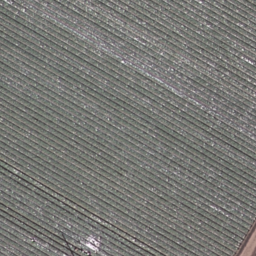

In [ ]:
ucmerced_train[1][0]